### flow
1. read data
2. check data dtypes
3. compare the corr with target column (features selection)
4. check the multicolinearity
5. fill mean values to feature columns
6. train test split
7. compare model with cross validation
8. train model and predict output
9. optimize hyperparameters using optuna
10. retrain model and predict output with the optimize hyperparameters

### Import

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import r2_score, root_mean_squared_error, make_scorer, mean_absolute_error

In [47]:
warnings.filterwarnings('ignore')

In [48]:
df = pd.read_csv('data/wage.csv')
df

,id,nearc2,nearc4,educ,age,fatheduc,motheduc,weight,momdad14,sinmom14,step14,reg661,reg662,reg663,reg664,reg665,reg666,reg667,reg668,reg669,south66,black,smsa,south,smsa66,wage,enroll,KWW,IQ,married,libcrd14,exper,lwage,expersq
0,2,0,0,7,29,NaN,NaN,158413,1,0,0,1,0,0,0,0,0,0,0,0,0,1,1,0,1,548,0,15.0,NaN,1.0,0.0,16,"6,306274891",256
1,3,0,0,12,27,8.0,8.0,380166,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,481,0,35.0,93.0,1.0,1.0,9,"6,175867081",81
2,4,0,0,12,34,14.0,12.0,367470,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,721,0,42.0,103.0,1.0,1.0,16,"6,580638885",256
3,5,1,1,11,27,11.0,12.0,380166,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,250,0,25.0,88.0,1.0,1.0,10,"5,52146101",100
4,6,1,1,12,34,8.0,7.0,367470,1,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,1,729,0,34.0,108.0,1.0,0.0,16,"6,591673851",256
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3005,5218,0,1,12,25,8.0,12.0,82135,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,335,0,15.0,NaN,1.0,0.0,7,"5,814129829",49
3006,5219,0,1,13,34,NaN,NaN,88765,1,0,0,0,0,0,0,0,1,0,0,0,1,0,1,1,0,481,0,43.0,NaN,1.0,1.0,15,"6,175867081",225
3007,5220,0,1,12,24,11.0,NaN,89271,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,500,0,25.0,109.0,1.0,0.0,6,"6,214608192",36
3008,5221,0,1,12,31,NaN,NaN,110376,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,713,0,32.0,107.0,1.0,1.0,13,"6,569480896",169


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3010 entries, 0 to 3009
Data columns (total 34 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        3010 non-null   int64  
 1   nearc2    3010 non-null   int64  
 2   nearc4    3010 non-null   int64  
 3   educ      3010 non-null   int64  
 4   age       3010 non-null   int64  
 5   fatheduc  2320 non-null   float64
 6   motheduc  2657 non-null   float64
 7   weight    3010 non-null   int64  
 8   momdad14  3010 non-null   int64  
 9   sinmom14  3010 non-null   int64  
 10  step14    3010 non-null   int64  
 11  reg661    3010 non-null   int64  
 12  reg662    3010 non-null   int64  
 13  reg663    3010 non-null   int64  
 14  reg664    3010 non-null   int64  
 15  reg665    3010 non-null   int64  
 16  reg666    3010 non-null   int64  
 17  reg667    3010 non-null   int64  
 18  reg668    3010 non-null   int64  
 19  reg669    3010 non-null   int64  
 20  south66   3010 non-null   int64  
 21  bl

### Feature selection

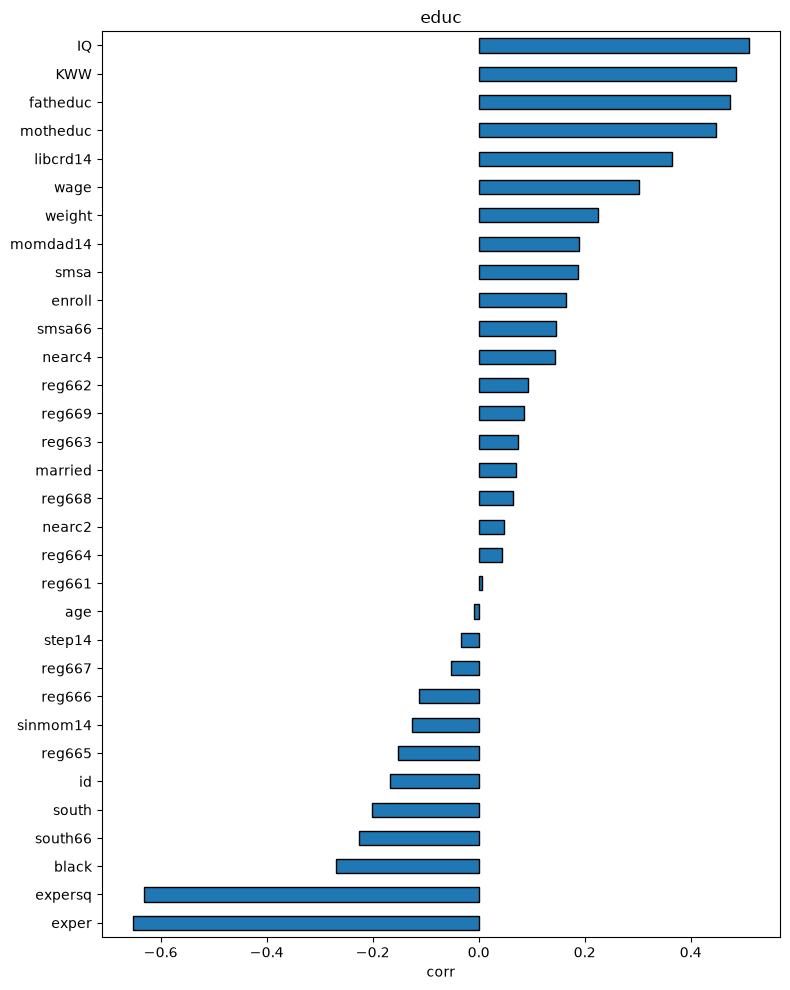

In [50]:
target_col = (
    df.corr(numeric_only=True)['educ']
    .drop('educ')
    .sort_values()
)

plt.figure(figsize=(8,10))

target_col.plot(
    kind="barh",
    edgecolor='black'
)

plt.title("educ")
plt.xlabel('corr')
plt.tight_layout()
plt.show()

In [51]:
feature_cols = ['exper', 'expersq', 'black', 'south66', 'enroll', 'smsa',
                'momdad14', 'weight', 'wage', 'libcrd14', 'motheduc', 'fatheduc',
                'KWW', 'IQ', 'educ']

temp = df[feature_cols]
temp.isnull().sum()

exper         0
expersq       0
black         0
south66       0
enroll        0
smsa          0
momdad14      0
weight        0
wage          0
libcrd14     13
motheduc    353
fatheduc    690
KWW          47
IQ          949
educ          0
dtype: int64

In [52]:
null_cols = ['libcrd14', 'motheduc', 'fatheduc', 'KWW', 'IQ']
for col in null_cols:
    temp[col] = temp[col].fillna(temp[col].mean())

temp.isnull().sum()

exper       0
expersq     0
black       0
south66     0
enroll      0
smsa        0
momdad14    0
weight      0
wage        0
libcrd14    0
motheduc    0
fatheduc    0
KWW         0
IQ          0
educ        0
dtype: int64

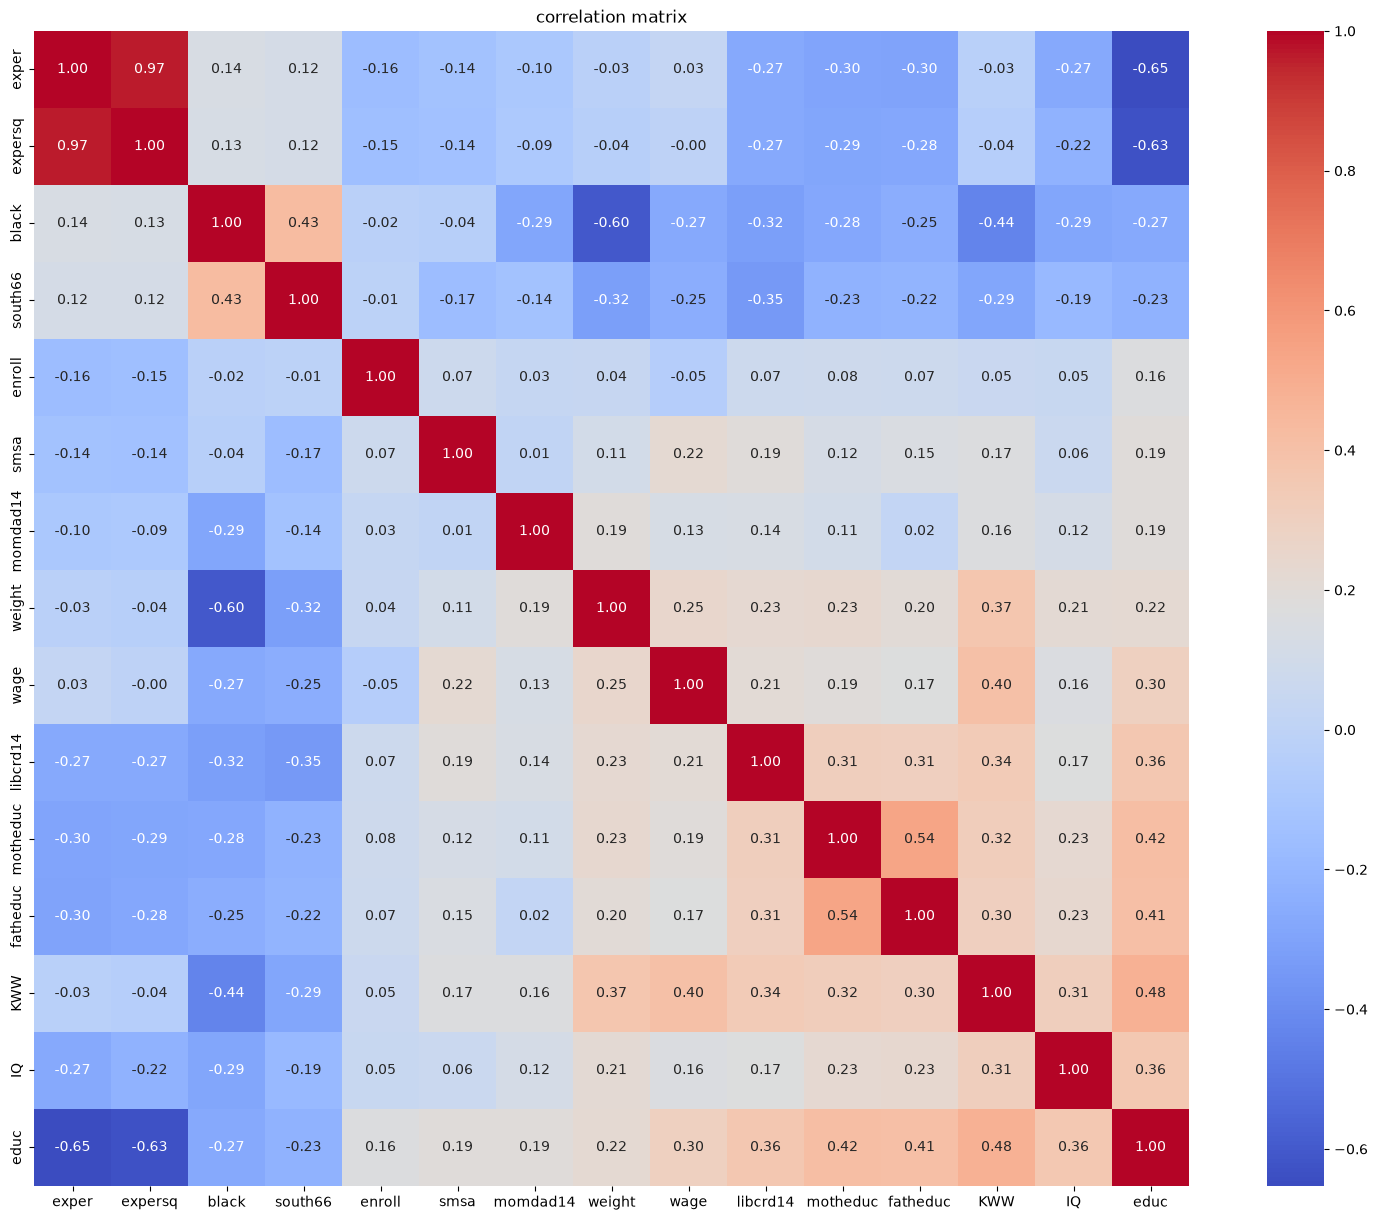

In [53]:
mat = temp.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(
    mat,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True)

plt.title('correlation matrix')
plt.show()

In [55]:
target = 'educ'

y = temp.pop(target)
X = temp


x_train, x_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2,
                                                    random_state=42)

                                                    
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

x_train_sc.shape, x_test_sc.shape, y_train.shape, y_test.shape

((2408, 14), (602, 14), (2408,), (602,))

In [56]:
def model_comparison_evaluate(regressors, X, y, n_splits=5):
    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scoring_metrics = {
        'r2': 'r2',
        'RMSE': 'neg_root_mean_squared_error',
        'MAE': 'neg_mean_absolute_error',
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in regressors.items():

        print(f'Model: {name}')

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {np.abs(scores).mean():.4f} | '
                f'Std = {np.abs(scores).std():.4f}'
            )

        print('\n')

In [57]:
regs = {
    'Ridge': Ridge(
        alpha=0.5
    ),

    'Lasso': Lasso(
        alpha=0.5
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        n_jobs=-1,
        random_state=42,
    )
}
model_comparison_evaluate(regs, X, y)

K-Fold Cross-Validation Evaluation

Model: Ridge
r2        : Mean = 0.6766 | Std = 0.0096
RMSE      : Mean = 1.5218 | Std = 0.0263
MAE       : Mean = 1.2047 | Std = 0.0181


Model: Lasso
r2        : Mean = 0.6340 | Std = 0.0090
RMSE      : Mean = 1.6190 | Std = 0.0243
MAE       : Mean = 1.3138 | Std = 0.0169


Model: Random Forest
r2        : Mean = 0.7477 | Std = 0.0137
RMSE      : Mean = 1.3440 | Std = 0.0393
MAE       : Mean = 0.9991 | Std = 0.0212




In [62]:
# Ridge Regression
ridge = Ridge(
    alpha=0.0010086803119648974
)

# Lasso Regression
lasso = Lasso(
    alpha=0.0010031179862369259
)

# Random Forest
rf = RandomForestRegressor(
    n_estimators=363,
    max_depth=7,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
    random_state=42,
    n_jobs=-1,
)

ridge.fit(x_train_sc, y_train)
lasso.fit(x_train_sc, y_train)
rf.fit(x_train_sc, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",363
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max

In [65]:
lr_y_pred = ridge.predict(x_test_sc)
ls_y_pred = lasso.predict(x_test_sc)
rf_y_pred = rf.predict(x_test_sc)

print("Ridge")
print(f'r2  : {r2_score(y_test, lr_y_pred):.4f}')
print(f'rmse: {root_mean_squared_error(y_test, lr_y_pred):.4f}')
print(f'mae : {mean_absolute_error(y_test, lr_y_pred):.4f}')

print("\nLasso")
print(f'r2  : {r2_score(y_test, ls_y_pred):.4f}')
print(f'rmse: {root_mean_squared_error(y_test, ls_y_pred):.4f}')
print(f'mae : {mean_absolute_error(y_test, ls_y_pred):.4f}')

print("\nRandom Forest")
print(f'r2  : {r2_score(y_test, rf_y_pred):.4f}')
print(f'rmse: {root_mean_squared_error(y_test, rf_y_pred):.4f}')
print(f'mae : {mean_absolute_error(y_test, rf_y_pred):.4f}')

Ridge
r2  : 0.6668
rmse: 1.5003
mae : 1.1930

Lasso
r2  : 0.6666
rmse: 1.5008
mae : 1.1941

Random Forest
r2  : 0.7147
rmse: 1.3884
mae : 1.0347
